<a href="https://colab.research.google.com/github/Ocean1407/pancreatic-cancer-ml/blob/main/Cancer_Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
drive.mount('/content/drive')
data = pd.read_csv("/content/drive/MyDrive/Pancreatic_Cancer_Files/Pancreatic_Cancer_Dataset.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
data.head()

,sample_id,patient_cohort,sample_origin,age,sex,diagnosis,stage,benign_sample_diagnosis,plasma_CA19_9,creatinine,LYVE1,REG1B,TFF1,REG1A
0,S1,Cohort1,BPTB,33,F,1,NaN,NaN,11.7,1.83222,0.893219,52.94884,654.282174,1262.000
1,S10,Cohort1,BPTB,81,F,1,NaN,NaN,NaN,0.97266,2.037585,94.46703,209.488250,228.407
2,S100,Cohort2,BPTB,51,M,1,NaN,NaN,7.0,0.78039,0.145589,102.36600,461.141000,NaN
3,S101,Cohort2,BPTB,61,M,1,NaN,NaN,8.0,0.70122,0.002805,60.57900,142.950000,NaN
4,S102,Cohort2,BPTB,62,M,1,NaN,NaN,9.0,0.21489,0.000860,65.54000,41.088000,NaN


In [3]:
data.describe()

,age,diagnosis,plasma_CA19_9,creatinine,LYVE1,REG1B,TFF1,REG1A
count,590.000000,590.000000,350.000000,590.000000,590.000000,590.000000,590.000000,306.000000
mean,59.079661,2.027119,654.002944,0.855383,3.063530,111.774090,597.868722,735.281222
std,13.109520,0.804873,2430.317642,0.639028,3.438796,196.267110,1010.477245,1477.247724
min,26.000000,1.000000,0.000000,0.056550,0.000129,0.001104,0.005293,0.000000
25%,50.000000,1.000000,8.000000,0.373230,0.167179,10.757216,43.961000,80.692000
50%,60.000000,2.000000,26.500000,0.723840,1.649862,34.303353,259.873974,208.538500
75%,69.000000,3.000000,294.000000,1.139482,5.205037,122.741013,742.736000,649.000000
max,89.000000,3.000000,31000.000000,4.116840,23.890323,1403.897600,13344.300000,13200.000000


<Axes: >

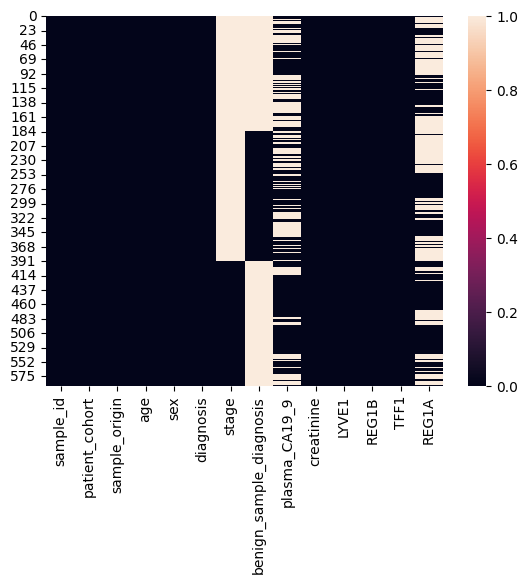

In [4]:
sns.heatmap(data.isnull())

In [5]:
data = data.drop(columns=[
    'stage',
    'benign_sample_diagnosis',
    'sample_id',
    'patient_cohort',
    'sample_origin'
], errors='ignore')

data['sex'] = data['sex'].map({'F': 0, 'M': 1})

y = data['diagnosis']
X = data.drop(columns=['diagnosis'])

# Split BEFORE any fitting (stratify keeps class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Pipeline handles imputation safely (fitted on train only)
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.751412429378531
              precision    recall  f1-score   support

           1       0.76      0.69      0.72        55
           2       0.68      0.63      0.66        62
           3       0.80      0.93      0.86        60

    accuracy                           0.75       177
   macro avg       0.75      0.75      0.75       177
weighted avg       0.75      0.75      0.75       177



<Axes: xlabel='diagnosis'>

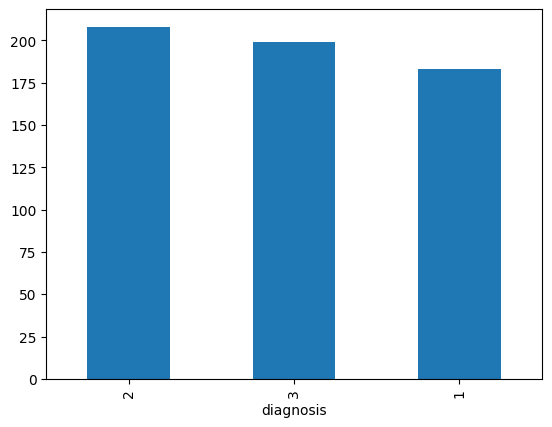

In [6]:
data["diagnosis"].value_counts().plot(kind="bar")

In [7]:
y_pred

array([2, 1, 3, 2, 3, 2, 3, 2, 2, 2, 3, 3, 1, 1, 3, 3, 1, 2, 3, 1, 3, 2,
       2, 2, 1, 2, 2, 1, 3, 2, 2, 1, 1, 3, 1, 3, 3, 2, 2, 2, 1, 2, 1, 2,
       3, 3, 3, 3, 2, 1, 3, 3, 3, 3, 2, 2, 2, 1, 3, 1, 1, 3, 3, 2, 1, 3,
       3, 3, 1, 3, 2, 1, 2, 3, 3, 1, 3, 1, 3, 1, 3, 2, 1, 1, 2, 3, 2, 2,
       1, 3, 2, 2, 2, 2, 2, 3, 3, 1, 1, 2, 2, 1, 1, 1, 3, 3, 3, 3, 1, 2,
       2, 2, 3, 1, 3, 3, 2, 2, 1, 3, 1, 1, 3, 1, 1, 2, 1, 2, 1, 3, 2, 3,
       3, 3, 1, 3, 1, 1, 3, 1, 3, 3, 3, 3, 2, 3, 1, 2, 3, 3, 3, 3, 2, 1,
       3, 1, 3, 2, 2, 1, 1, 2, 3, 2, 3, 3, 1, 2, 1, 2, 3, 3, 3, 2, 2, 3,
       2])

In [8]:
y_test

,diagnosis
17,1
34,1
507,3
300,2
443,3
...,...
479,3
354,2
251,2
380,2


In [9]:
# Evaluate the model's accuracy

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.751412429378531


In [10]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           1       0.76      0.69      0.72        55
           2       0.68      0.63      0.66        62
           3       0.80      0.93      0.86        60

    accuracy                           0.75       177
   macro avg       0.75      0.75      0.75       177
weighted avg       0.75      0.75      0.75       177

